# Community Citation Analysis 

Making use of a community citation analysis to identify groups/communities in the behavious of works citing each other.

In [37]:
#import necessary packages
import networkx as nx
import numpy as np
from community import community_louvain #pip install python-louvain package
import leidenalg as la
import igraph as ig
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Read the data

Read the data generated by get_data_openalex.ipynb notebook.

In [38]:
fake_data = 0
toprint = 0 #Flag to print information (turn off if using a large dataset!)

In [39]:
# Load the data
data_file = '../data/openAlex/test/pub2ref_OA.csv'
if fake_data == 1: 
    data_file = '../data/fake/citation_data_fake.csv'
citation_data = pd.read_csv(data_file)

#citation_data = citation_data[0:1000]

In [40]:
print("Information of the data being used:")
print()
citation_data.info()
print()
print(citation_data.head(20))

Information of the data being used:

<class 'pandas.DataFrame'>
RangeIndex: 29276 entries, 0 to 29275
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   publication_id  29276 non-null  str  
 1   reference_id    29276 non-null  str  
dtypes: str(2)
memory usage: 2.2 MB

                      publication_id                      reference_id
0   https://openalex.org/W2184854514     https://openalex.org/W9119819
1   https://openalex.org/W2184854514    https://openalex.org/W35899286
2   https://openalex.org/W2184854514   https://openalex.org/W627963485
3   https://openalex.org/W2184854514   https://openalex.org/W768552817
4   https://openalex.org/W2184854514  https://openalex.org/W1499933681
5   https://openalex.org/W2184854514  https://openalex.org/W1549940068
6   https://openalex.org/W2184854514  https://openalex.org/W1565485882
7   https://openalex.org/W2184854514  https://openalex.org/W1574930552
8   https://openal

## Perform the community analysis

Makes use [networkx](https://networkx.org/documentation/stable/) package, [igraph](https://python.igraph.org/en/stable/) package.

### Set up the graphs 

A `Graph` is a collection of nodes (in this case, works) and edges (in this case lines representing citations between works). Should identify pairs of nodes (i.e., in this case, two works that have a citation link between them). We are using OpenAlex IDs to define nodes in this example. Our tables are effectively a long list of edges because we have created a list of every pair of citations (sources and targets or publication_ids and reference_ids). So we use the citation_data to add all of these edges to the Graph.

With `iGraph` object, we can do fast manipulation and analysis. [`ig.Graph.TupleList`](https://python.igraph.org/en/main/api/igraph.Graph.html#TupleList) constructs a graph for a list of tuples (which is what we had in out `Graph`. We have set directed=True, which I think keeps track of the direction of the edge (i.e., which is the citing and which is the cited work in this case).

In [41]:
# Create a directed graph
G_networkX = nx.DiGraph()#create an empty graph

if fake_data == 1:
    G_networkX.add_edges_from(citation_data[['source', 'target']].values) 
else: G_networkX.add_edges_from(citation_data[['publication_id', 'reference_id']].values) #create the edges

# Convert the NetworkX graph to an iGraph object
g_iGraph = ig.Graph.TupleList(G_networkX.edges(), directed=True)

### Perform the partition

Uses the [leidenalg](https://leidenalg.readthedocs.io/en/stable/intro.html) package. This is seems to be behaving well on the fake data I generated, recovering the citation communities I artificially created.

In [42]:
# Perform Leiden community detection (note the number of iterations is how many times the algorithm is used, if make it negative then runs until not improvement)
partition = la.find_partition(g_iGraph, la.ModularityVertexPartition, n_iterations=-3)

# Get the community assignments
community_ids = partition.membership

In [47]:
la.find_partition?

Signature:
la.find_partition(
    graph,
    partition_type,
    initial_membership=None,
    weights=None,
    n_iterations=2,
    max_comm_size=0,
    seed=None,
    **kwargs,
)
Docstring:
Detect communities using the default settings.

This function detects communities given the specified method in the
``partition_type``. This should be type derived from
:class:`VertexPartition.MutableVertexPartition`, e.g.
:class:`ModularityVertexPartition` or :class:`CPMVertexPartition`. Optionally
an initial membership and edge weights can be provided. Remaining
``**kwargs`` are passed on to the constructor of the ``partition_type``,
including for example a ``resolution_parameter``.

Parameters
----------
graph : :class:`ig.Graph`
  The graph for which to detect communities.

partition_type : type of :class:`
  The type of partition to use for optimisation.

initial_membership : list of int
  Initial membership for the partition. If :obj:`None` then defaults to a
  singleton partition.

weights :

### Tidy and print some information about the communities identified

In [43]:
if toprint == 1: 
    print(partition)
print()

#Print overview of communities identied
print("")
print("----Partition Overview----")
print("Number of nodes (elements):",partition.n)
print("Number of communities:",len(partition))
print("")



----Partition Overview----
Number of nodes (elements): 22106
Number of communities: 217



In [44]:
# Create a dictionary mapping nodes to community IDs
node_community = {node: community_id for node, community_id in zip(G_networkX.nodes(), community_ids)}

### Calculate some community metrics

Will go to each community and get the size (i.e., the number of works in the community) and density of each of these.

The [density](https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.density.html) is 0 for a graph without edges and 1 for a complete graph. The density of multigraphs can be higher than 1.

In [45]:
community_nodes_list = []

#Create a dictionary of the information about the community metrics
community_metrics = {}
for community_id in set(community_ids):
    #get number of works (nodes) in each community
    community_nodes = [node for node, cid in node_community.items() if cid == community_id]
    #get density in each node [what is this?!?!]
    community_nodes_list.append(community_nodes)
    community_graph = G_networkX.subgraph(community_nodes)
    community_metrics[community_id] = {
        'size': len(community_nodes),
        'density': nx.density(community_graph)
    }

# Print community metrics (number of papers in each community and the density)
for community_id, metrics in community_metrics.items():
    print(f"Community {community_id}: size={metrics['size']}, density={metrics['density']}")
print("-------------")
print("")
if toprint == 1: print(community_metrics)

Community 0: size=1801, density=0.00035258189894503053
Community 1: size=1270, density=0.0003108653971445059
Community 2: size=1152, density=0.00040423786079737424
Community 3: size=1088, density=0.0006603779966448401
Community 4: size=531, density=0.0004050740859183456
Community 5: size=524, density=0.0008647993811393459
Community 6: size=469, density=0.000574052812858783
Community 7: size=451, density=0.0014831239221483124
Community 8: size=394, density=0.0010010203949832733
Community 9: size=389, density=0.0015371160522619457
Community 10: size=367, density=0.0008412620419588749
Community 11: size=360, density=0.0007195914577530177
Community 12: size=359, density=0.0014939076578329002
Community 13: size=349, density=0.0011197839475677635
Community 14: size=328, density=0.0009416722607593048
Community 15: size=324, density=0.0015862095325459619
Community 16: size=321, density=0.0011292834890965732
Community 17: size=302, density=0.00084706607115355
Community 18: size=278, density=0.0

<h1>Make figure</h1>

In [81]:
#testing that everything is consistent
if toprint ==1:
    print(list(G_networkX.nodes()))
    print()
    print(list(node_community.values()))
    print()
    print(community_ids)
    print()
    for keys,values in node_community.items():
        print(keys,values)

['WOS:000279731700007', 'WOS:000279731700009', 'WOS:000396401600013', 'WOS:000365063100009', 'WOS:001265701800001', 'WOS:000587608600026', 'WOS:000492417900009', 'WOS:000380450900007', 'WOS:001336892600004', 'WOS:000274369800014', 'WOS:001381043200001', 'WOS:000380410400105', 'WOS:001087472600001', 'WOS:000310847300019', 'WOS:001259864900041', 'WOS:000278584300025', 'WOS:001337593100008', 'WOS:000484590300001', 'WOS:001352180500100', 'WOS:000519098200104', 'WOS:001337581700004', 'WOS:000243205900006', 'WOS:000345168400011', 'WOS:000674894000002', 'WOS:001062040400001', 'WOS:000573482500002']

[0, 0, 2, 0, 0, 0, 0, 0, 2, 4, 2, 2, 2, 3, 3, 4, 3, 3, 4, 4, 1, 1, 1, 1, 1, 1]

[0, 0, 2, 0, 0, 0, 0, 0, 2, 4, 2, 2, 2, 3, 3, 4, 3, 3, 4, 4, 1, 1, 1, 1, 1, 1]

WOS:000279731700007 0
WOS:000279731700009 0
WOS:000396401600013 2
WOS:000365063100009 0
WOS:001265701800001 0
WOS:000587608600026 0
WOS:000492417900009 0
WOS:000380450900007 0
WOS:001336892600004 2
WOS:000274369800014 4
WOS:001381043200001 

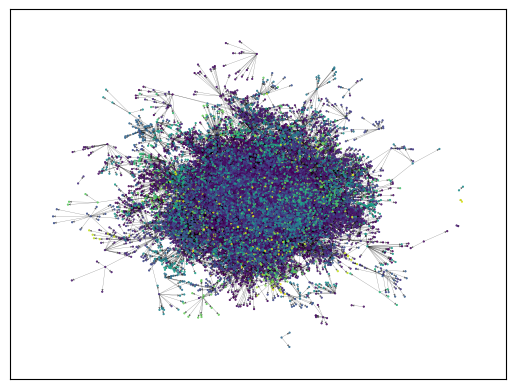

In [46]:
# Sort out colors to match the community IDs ***not working**

colors = community_ids
if toprint == 1:
    print("")
    print(G_networkX.nodes())
    print(colors)
    

#Plotting options
options = {
    'node_size': 10,
    'width': 0.1,
    'arrowsize': 5,
    'with_labels': False
}

node_size = 0.3

pos = nx.spring_layout(G_networkX)
cmap = plt.get_cmap('hsv', max(node_community.values()) + 1)

nx.draw_networkx_nodes(G_networkX, pos, nodelist=node_community.keys(), node_size=0.3, node_color=node_community.values())
nx.draw_networkx_edges(G_networkX, pos, alpha=0.5, width=0.2, arrowsize=3,node_size=node_size+0.2)

plt.savefig("../output/figures/output_OA.png",dpi=800)
plt.show()

In [12]:
nx.draw_networkx_nodes?

Signature:
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=None,
    node_size=300,
    node_color='#1f78b4',
    node_shape='o',
    alpha=None,
    cmap=None,
    vmin=None,
    vmax=None,
    ax=None,
    linewidths=None,
    edgecolors=None,
    label=None,
    margins=None,
    hide_ticks=True,
)
Docstring:
Draw the nodes of the graph G.

This draws only the nodes of the graph G.

Parameters
----------
G : graph
    A networkx graph

pos : dictionary
    A dictionary with nodes as keys and positions as values.
    Positions should be sequences of length 2.

ax : Matplotlib Axes object, optional
    Draw the graph in the specified Matplotlib axes.

nodelist : list (default list(G))
    Draw only specified nodes

node_size : scalar or array (default=300)
    Size of nodes.  If an array it must be the same length as nodelist.

node_color : color or array of colors (default='#1f78b4')
    Node color. Can be a single color or a sequence of colors with the same
    length as nodeli

In [56]:
[key for key, value in node_community.items() if value == 0]

['WOS:000279731700007',
 'WOS:000279731700009',
 'WOS:000365063100009',
 'WOS:001265701800001',
 'WOS:000587608600026',
 'WOS:000492417900009',
 'WOS:000380450900007']

In [57]:
[key for key, value in node_community.items() if value == 1]

['WOS:001337581700004',
 'WOS:000243205900006',
 'WOS:000345168400011',
 'WOS:000674894000002',
 'WOS:001062040400001',
 'WOS:000573482500002']

In [61]:
G_networkX.nodes()

NodeView(('WOS:000279731700007', 'WOS:000279731700009', 'WOS:000396401600013', 'WOS:000365063100009', 'WOS:001265701800001', 'WOS:000587608600026', 'WOS:000492417900009', 'WOS:000380450900007', 'WOS:001336892600004', 'WOS:000274369800014', 'WOS:001381043200001', 'WOS:000380410400105', 'WOS:001087472600001', 'WOS:000310847300019', 'WOS:001259864900041', 'WOS:000278584300025', 'WOS:001337593100008', 'WOS:000484590300001', 'WOS:001352180500100', 'WOS:000519098200104', 'WOS:001337581700004', 'WOS:000243205900006', 'WOS:000345168400011', 'WOS:000674894000002', 'WOS:001062040400001', 'WOS:000573482500002'))

In [18]:
G_networkX.get_edge_data?

Signature: G_networkX.get_edge_data(u, v, default=None)
Docstring:
Returns the attribute dictionary associated with edge (u, v).

This is identical to `G[u][v]` except the default is returned
instead of an exception if the edge doesn't exist.

Parameters
----------
u, v : nodes
default:  any Python object (default=None)
    Value to return if the edge (u, v) is not found.

Returns
-------
edge_dict : dictionary
    The edge attribute dictionary.

Examples
--------
>>> G = nx.path_graph(4)  # or DiGraph, MultiGraph, MultiDiGraph, etc
>>> G[0][1]
{}

But it is safe to assign attributes `G[u][v]['foo']`

>>> G[0][1]["weight"] = 7
>>> G[0][1]["weight"]
7
>>> G[1][0]["weight"]
7

>>> G = nx.path_graph(4)  # or DiGraph, MultiGraph, MultiDiGraph, etc
>>> G.get_edge_data(0, 1)  # default edge data is {}
{}
>>> e = (0, 1)
>>> G.get_edge_data(*e)  # tuple form
{}
>>> G.get_edge_data("a", "b", default=0)  # edge not in graph, return 0
0
File:      ~/miniconda3/envs/si_citation_analysis/lib/python

In [64]:
nx.draw_networkx_edges?

Signature:
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=None,
    width=1.0,
    edge_color='k',
    style='solid',
    alpha=None,
    arrowstyle=None,
    arrowsize=10,
    edge_cmap=None,
    edge_vmin=None,
    edge_vmax=None,
    ax=None,
    arrows=None,
    label=None,
    node_size=300,
    nodelist=None,
    node_shape='o',
    connectionstyle='arc3',
    min_source_margin=0,
    min_target_margin=0,
    hide_ticks=True,
)
Docstring:
Draw the edges of the graph G.

This draws only the edges of the graph G.

Parameters
----------
G : graph
    A networkx graph

pos : dictionary
    A dictionary with nodes as keys and positions as values.
    Positions should be sequences of length 2.

edgelist : collection of edge tuples (default=G.edges())
    Draw only specified edges

width : float or array of floats (default=1.0)
    Line width of edges

edge_color : color or array of colors (default='k')
    Edge color. Can be a single color or a sequence of colors with the same
  

In [45]:
node_community.values()

dict_values([0, 0, 2, 0, 0, 0, 0, 0, 2, 4, 2, 2, 2, 3, 3, 4, 3, 3, 4, 4, 1, 1, 1, 1, 1, 1])

In [36]:
def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)

cmap = get_cmap(5)
type(cmap)

/var/folders/ny/5knc_9j57gx54mx6yn23ds200000gp/T/ipykernel_7909/1659495999.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)


matplotlib.colors.LinearSegmentedColormap

In [25]:
np.array(list((node_community.values())))

array([0, 0, 2, 0, 0, 0, 0, 0, 2, 4, 2, 2, 2, 3, 3, 4, 3, 3, 4, 4, 1, 1,
       1, 1, 1, 1])

In [18]:
nx.draw_networkx_nodes?

Signature:
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=None,
    node_size=300,
    node_color='#1f78b4',
    node_shape='o',
    alpha=None,
    cmap=None,
    vmin=None,
    vmax=None,
    ax=None,
    linewidths=None,
    edgecolors=None,
    label=None,
    margins=None,
    hide_ticks=True,
)
Docstring:
Draw the nodes of the graph G.

This draws only the nodes of the graph G.

Parameters
----------
G : graph
    A networkx graph

pos : dictionary
    A dictionary with nodes as keys and positions as values.
    Positions should be sequences of length 2.

ax : Matplotlib Axes object, optional
    Draw the graph in the specified Matplotlib axes.

nodelist : list (default list(G))
    Draw only specified nodes

node_size : scalar or array (default=300)
    Size of nodes.  If an array it must be the same length as nodelist.

node_color : color or array of colors (default='#1f78b4')
    Node color. Can be a single color or a sequence of colors with the same
    length as nodeli

## Trying with Louvain - not working at moment
Following: [https://github.com/taynaud/python-louvain](https://github.com/taynaud/python-louvain)

This might still be possible using [leidenalg package](https://leidenalg.readthedocs.io/en/stable/advanced.html) and can just edit above code

In [16]:
# compute the best partition using the louvian
#for key in partition:
#partition = community_louvain.best_partition(G_networkX)
#    print (key,partition[key])

In [17]:
# draw the graph
#pos = nx.spring_layout(G_networkX)
# color the nodes according to their partition
#cmap = plt.get_cmap('viridis', max(partition.values()) + 1)
#nx.draw_networkx_nodes(G_networkX, pos, partition.keys(), node_size=30,
#                       cmap=cmap, node_color=list(partition.values()))
#nx.draw_networkx_edges(G_networkX, pos, alpha=0.5)
#plt.show()

## Get community metrics and print results data